# LeetCode #61: Rotate List

https://leetcode.com/problems/rotate-list/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (rotate one at a time)** | $O(n \times k)$ | $O(1)$ |
| **Optimal: Close into circle** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
Rotate the list one position at a time, repeated `k` times. Each rotation moves the last node to the front. This is $O(n \times k)$ time which is very slow when `k` is large.

### Optimal: Close into Circle ★
1. Traverse to find the length `n` and the tail node.
2. Compute effective rotations: `k = k % n`. If `k == 0`, no rotation needed.
3. Connect tail to head, forming a circular list.
4. Advance `(n - k)` steps from the head to find the new tail.
5. The node after the new tail becomes the new head. Break the circle.

**Why this works:** Rotating right by `k` is equivalent to making the `(n - k)`-th node the new tail. By closing the list into a circle first, we simply pick the correct break point.

**Constraints:**
* `0 <= k <= 2 * 10^9` — must use modulo to avoid TLE.
* The list can be empty.

## Solutions

### C#

In [ ]:
// Definition for singly-linked list.
public class ListNode {
    public int val;
    public ListNode next;
    public ListNode(int val = 0, ListNode next = null) {
        this.val = val;
        this.next = next;
    }
}

public class Solution {
    public ListNode RotateRight(ListNode head, int k) {
        if (head == null || head.next == null || k == 0) return head;
        
        // Find length and tail
        int n = 1;
        ListNode tail = head;
        while (tail.next != null) {
            tail = tail.next;
            n++;
        }
        
        k %= n;
        if (k == 0) return head;
        
        // Close the circle
        tail.next = head;
        
        // Find new tail: (n - k) steps from head
        ListNode newTail = head;
        for (int i = 0; i < n - k - 1; i++) {
            newTail = newTail.next;
        }
        
        ListNode newHead = newTail.next;
        newTail.next = null;
        return newHead;
    }
}

### Python

In [ ]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

class Solution:
    def rotateRight(self, head: ListNode, k: int) -> ListNode:
        if not head or not head.next or k == 0:
            return head
        
        # Find length and tail
        n = 1
        tail = head
        while tail.next:
            tail = tail.next
            n += 1
        
        k %= n
        if k == 0:
            return head
        
        # Close the circle
        tail.next = head
        
        # Find new tail: (n - k) steps from head
        new_tail = head
        for _ in range(n - k - 1):
            new_tail = new_tail.next
        
        new_head = new_tail.next
        new_tail.next = None
        return new_head

### Go

In [ ]:
// Definition for singly-linked list.
// type ListNode struct {
//     Val  int
//     Next *ListNode
// }

func rotateRight(head *ListNode, k int) *ListNode {
    if head == nil || head.Next == nil || k == 0 {
        return head
    }
    
    // Find length and tail
    n := 1
    tail := head
    for tail.Next != nil {
        tail = tail.Next
        n++
    }
    
    k %= n
    if k == 0 {
        return head
    }
    
    // Close the circle
    tail.Next = head
    
    // Find new tail
    newTail := head
    for i := 0; i < n-k-1; i++ {
        newTail = newTail.Next
    }
    
    newHead := newTail.Next
    newTail.Next = nil
    return newHead
}

### Rust

In [ ]:
// Definition for singly-linked list.
// #[derive(PartialEq, Eq, Clone, Debug)]
// pub struct ListNode {
//     pub val: i32,
//     pub next: Option<Box<ListNode>>,
// }

impl Solution {
    pub fn rotate_right(head: Option<Box<ListNode>>, k: i32) -> Option<Box<ListNode>> {
        if head.is_none() {
            return None;
        }
        
        // Collect into vec for easier manipulation
        let mut nodes = Vec::new();
        let mut current = head;
        while let Some(mut node) = current {
            current = node.next.take();
            nodes.push(node);
        }
        
        let n = nodes.len();
        let k = (k as usize) % n;
        if k == 0 {
            // Rebuild original list
            let mut head = None;
            for mut node in nodes.into_iter().rev() {
                node.next = head;
                head = Some(node);
            }
            return head;
        }
        
        // Rotate: last k elements go to front
        nodes.rotate_right(k);
        
        // Rebuild list
        let mut head = None;
        for mut node in nodes.into_iter().rev() {
            node.next = head;
            head = Some(node);
        }
        head
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `head = [1, 2, 3, 4, 5], k = 2`

Walk through: Find length n=5. Effective k = 2%5 = 2. Close circle: 5→1. Advance n-k=3 steps from head to node 3 (new tail). New head = node 4. Break link after 3. Result: [4,5,1,2,3].

**Why tricky:** Classic rotation — the last k nodes move to the front. Interviewers verify you understand the circle-close/break technique and can find the correct break point at position n-k.

### 2. Slightly Complex — k Much Larger Than Length
**Input:** `head = [1, 2, 3], k = 2,000,000,000`

Walk through: n=3. Effective k = 2,000,000,000 % 3 = 2. Now proceed as normal: close circle, advance n-k=1 step, new head = node 2. Result: [2,3,1]. Without modulo, brute-force rotates 2 billion times — each is $O(n)$, total $O(n \times k) \approx 6 \times 10^9$ → TLE.

**Why tricky:** k can be up to $2 \times 10^9$. The modulo trick reduces it to at most n steps. Interviewers specifically test k >> n to catch TLE solutions. The key insight: rotating n times returns the list to its original state.

### 3. Edge Case: Time Factor — k is Exact Multiple of n
**Input:** `head = [1, 2, 3, 4, 5], k = 5,000,000`

Walk through: n=5. Effective k = 5,000,000 % 5 = 0. Return head immediately — no rotation needed. We skip the circle-close/break steps entirely. Total work: one traversal to find n, plus one modulo operation.

**Why tricky:** When k is a multiple of n, the list returns to its original configuration. The early return for k%n==0 is an optimization that avoids unnecessary pointer manipulation. Without it, you'd close the circle, advance n steps, and break at the same point — correct but wasteful.

### 4. Edge Case: Space Factor — Very Long List, k=1
**Input:** `head = [1, 2, 3, ..., 500], k = 1`

Walk through: n=500. k=1. Close circle, advance n-k=499 steps, break. New head = node 500. Result: [500, 1, 2, ..., 499]. Circle method uses $O(1)$ extra space — only pointer reassignment. An array-conversion approach would use $O(n) = O(500)$ extra space.

**Why tricky:** Some candidates convert to array, rotate, rebuild — $O(n)$ extra space. The circle method is in-place with $O(1)$ extra space regardless of list length. Interviewers look for this distinction.

### 5. Almost-Impossible but Plausible — Empty List and Single Node
**Input A:** `head = null, k = 5` | **Input B:** `head = [99], k = 2,000,000,000`

Walk through A: head is null → return null immediately (no traversal). Walk through B: n=1, k % 1 = 0 → return head unchanged. Any rotation of a single node is itself.

**Why tricky:** Two boundary traps: (1) null/empty list — must check before traversing to avoid NPE, (2) single node with enormous k — k%1=0 always, so no rotation. A missing null check causes a crash; forgetting that k%1=0 causes an unnecessary circle-close on a self-loop.

---

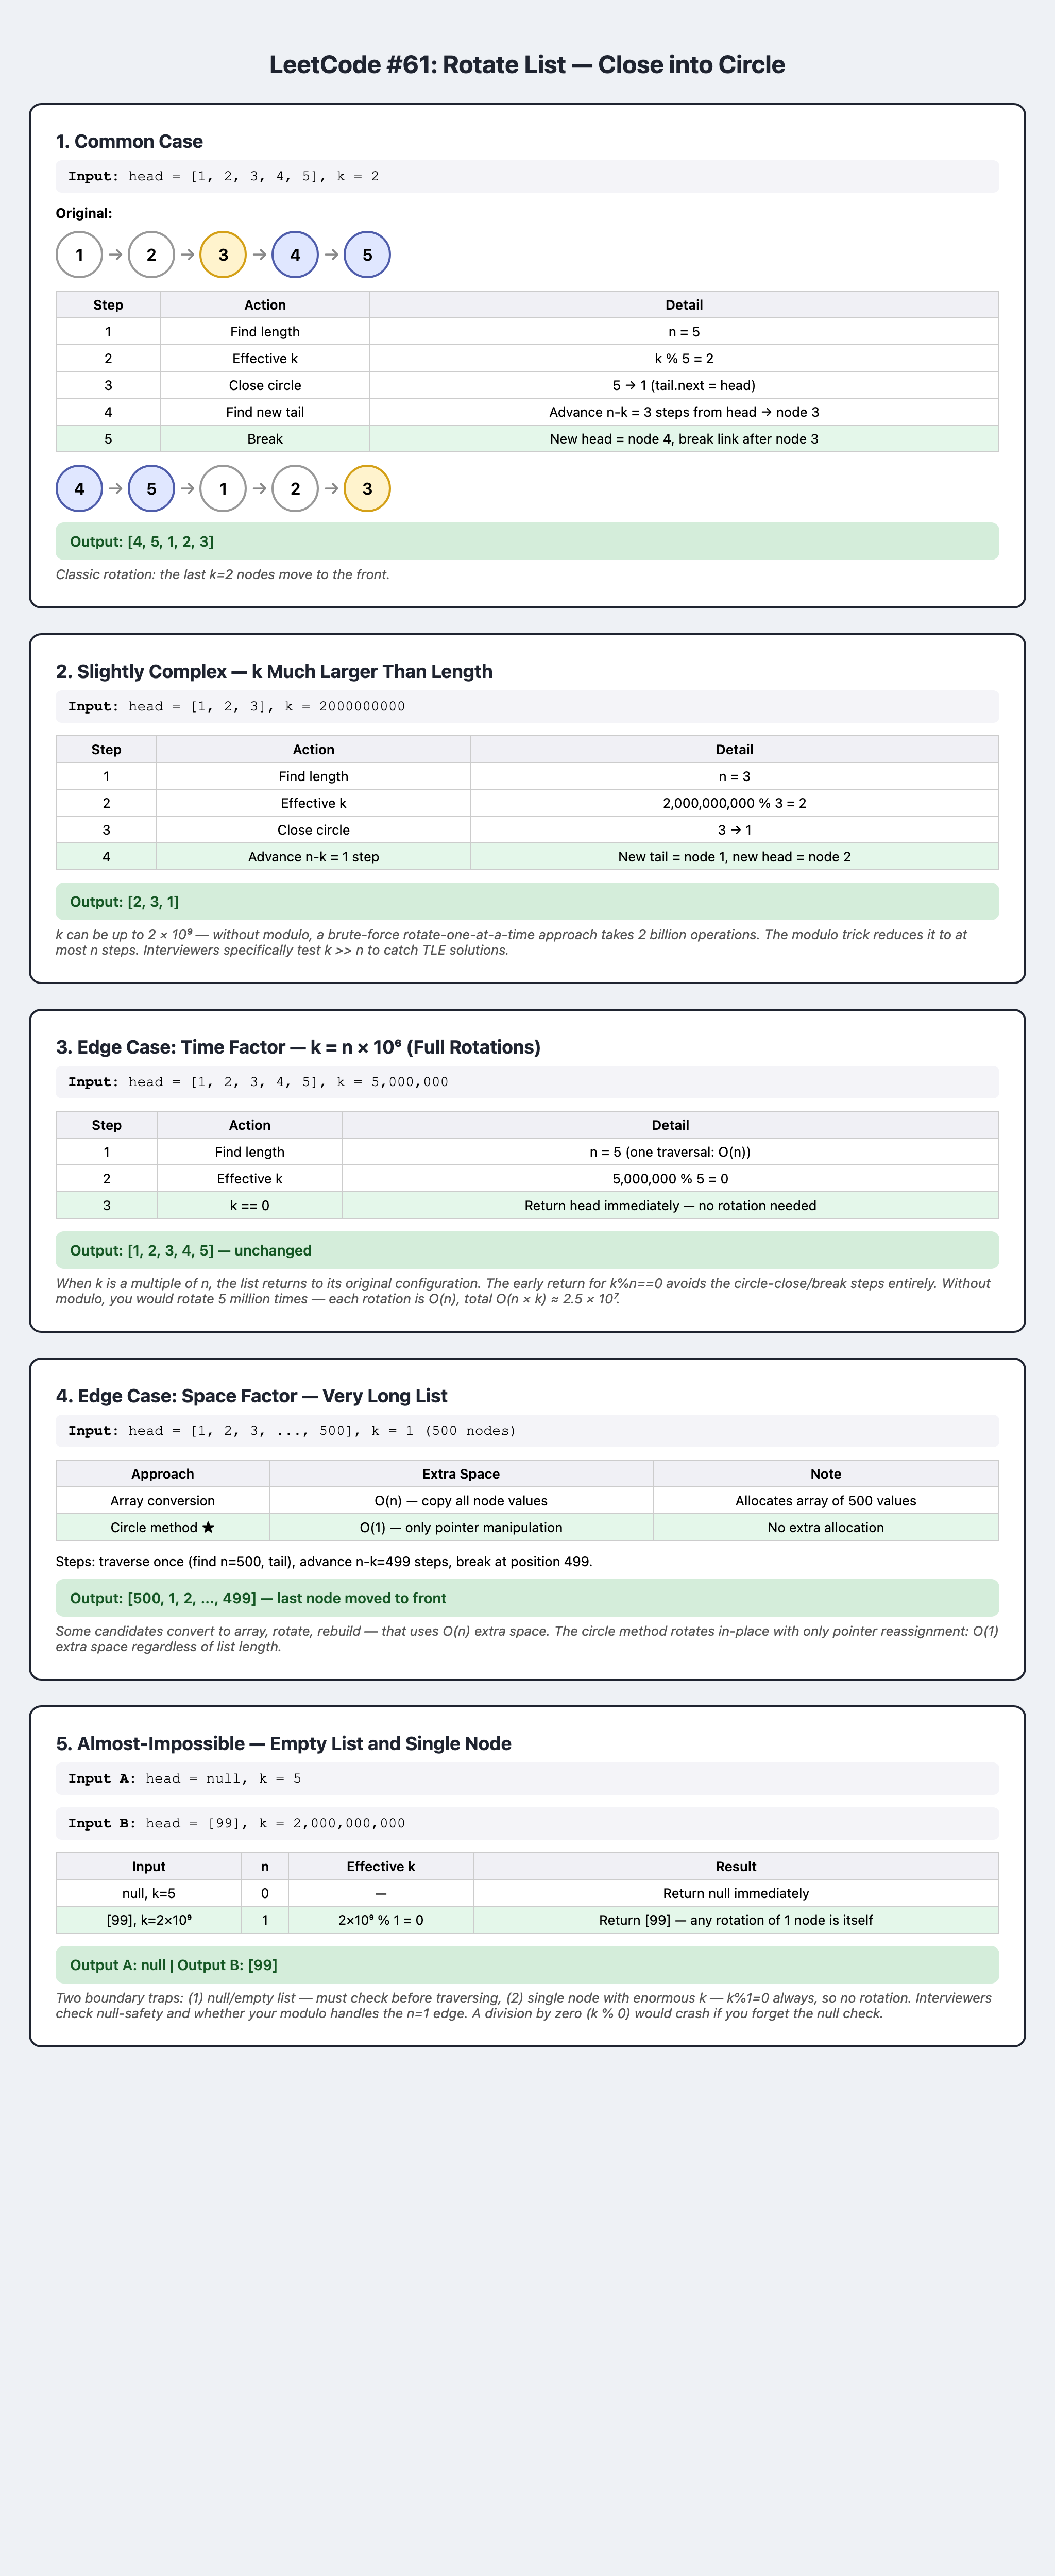